# Libs

In [1]:
%matplotlib inline

import os

import numpy as np
import scipy as sp
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import skimage
import cv2

import sys
sys.path.append(os.path.abspath('../'))

from scripts.BFmainlib import BF_image, HSV_threshold, HSV_transform

# Loading and segmenting image

In [2]:
image_paths = [f'../pictures/test_input_{i}.bmp' for i in range(1, 6)]

In [3]:
test_image_class = BF_image(verbose=False)

test_image_class.load_image('../pictures/test_input_5.bmp')
test_image_class.preprocess_image()
test_image_class.segment_image(type='ridges')

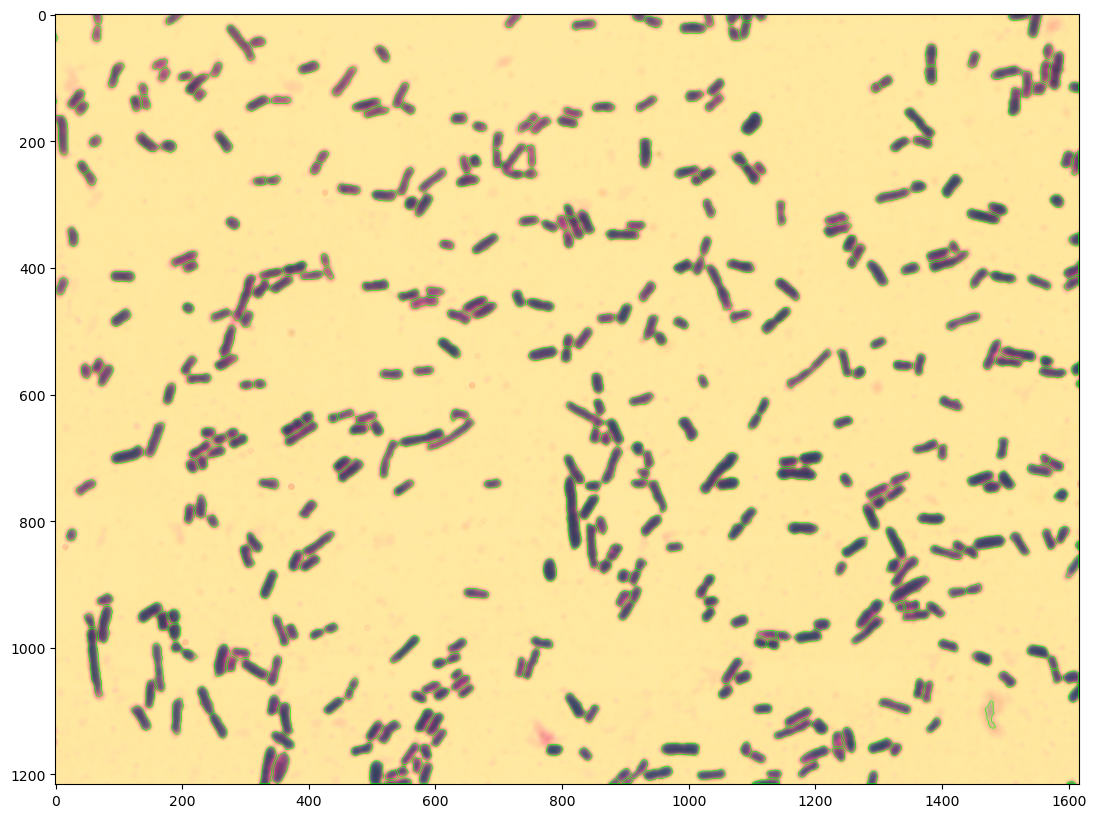

In [4]:
plt.figure(figsize=(14,10))
plt.imshow(test_image_class.segment_draw())
plt.show()

# Printing out info for classification

In [5]:
objects_features = test_image_class.all_object_features()

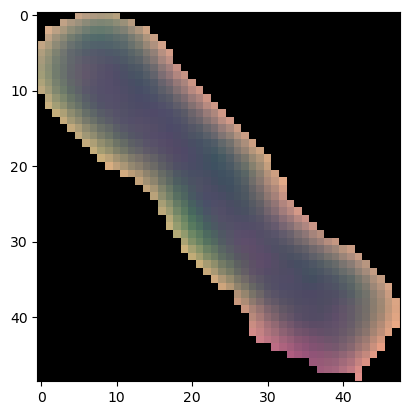

In [6]:
plt.imshow(objects_features['21']['masked_object'])
plt.show()

In [7]:
for key, value in objects_features['21'].items():
    if str(key) not in ['mask', 'masked_object']:
        print(f"{key}: {value}")

coords: {'x': 1341, 'y': 148, 'w': 48, 'h': 49}
color_props: {'red_peak': 85, 'green_peak': 77, 'blue_peak': 103, 'red_median': 103.0, 'green_median': 101.0, 'blue_median': 106.0}
region_props: {'perimeter': array([147.40916293]), 'area': array([923.]), 'axis_major_length': array([67.79054672]), 'axis_minor_length': array([18.07417008]), 'eccentricity': array([0.96380232]), 'orientation': array([0.75821725])}


# Constructing dataset

In [8]:
dataset = pd.DataFrame.from_dict([{'ID': key} | objects_features[key]['color_props'] | objects_features[key]['region_props']for key in objects_features], dtype=float)
dataset

,ID,red_peak,green_peak,blue_peak,red_median,green_median,blue_median,perimeter,area,axis_major_length,axis_minor_length,eccentricity,orientation
0,1.0,72.0,66.0,102.0,87.0,81.0,103.0,259.882251,2032.0,127.536389,21.001951,0.986348,0.093988
1,2.0,81.0,77.0,103.0,105.0,94.0,108.0,248.018290,1565.0,119.895397,17.234925,0.989614,0.116704
2,3.0,75.0,67.0,106.0,99.0,87.0,110.0,194.350288,1368.0,91.396109,20.300309,0.975021,-0.721159
3,4.0,70.0,65.0,112.0,108.0,82.0,114.0,169.580736,1279.0,73.255458,22.628413,0.951095,-1.026874
4,5.0,108.0,75.0,113.0,128.0,100.0,116.0,185.923882,1135.0,87.427692,17.627588,0.979463,0.422992
...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,445.0,92.0,98.0,113.0,139.0,136.5,119.0,32.692388,66.0,14.704816,6.148138,0.908399,0.049941
445,446.0,204.0,136.0,138.0,152.0,141.0,132.0,29.899495,49.0,13.619049,4.918753,0.932501,-1.563276
446,447.0,165.0,147.0,115.0,151.5,138.0,121.0,26.278175,46.0,11.648895,5.298003,0.890590,-0.007939
447,448.0,157.0,158.0,141.0,184.0,168.0,132.0,25.242641,41.0,12.815455,4.213197,0.944414,0.014037


# Analysing dataset

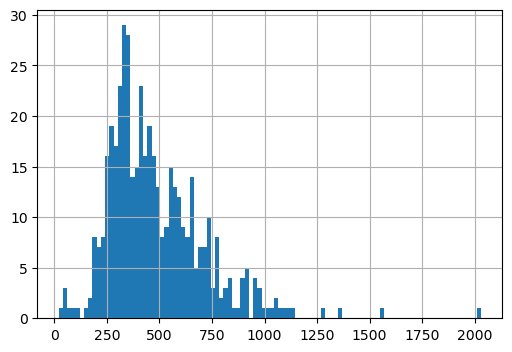

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(dataset['area'], bins=100)
plt.grid()
plt.show()

In [10]:
pca = PCA(n_components=2)
pca.fit(dataset.drop(columns = 'ID').values)

PCA(n_components=2)

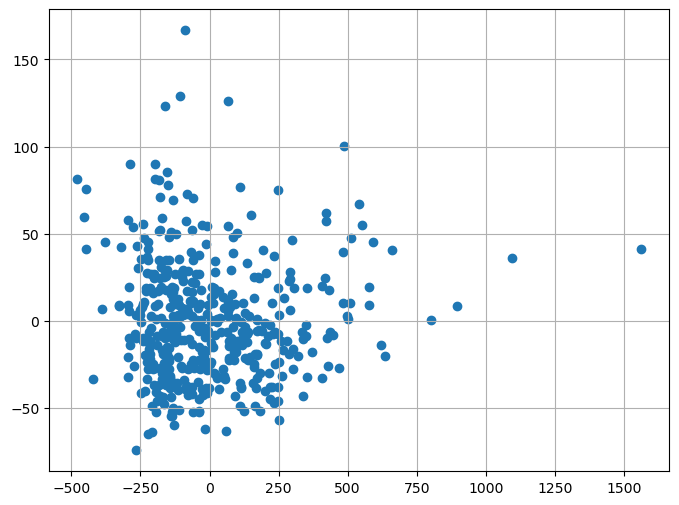

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(pca.transform(dataset.drop(columns = 'ID').values)[:,0], pca.transform(dataset.drop(columns = 'ID').values)[:,1])
plt.grid()
plt.show()

## checking PCA for different images

In [12]:
# fig, ax = plt.subplots(1,1, figsize=(12,10))
all_images_fobjects_dict = {}
all_images_fobjects_dataset = pd.DataFrame()
for i in [0, 1, 2, 4]:
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(image_paths[i])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    test_image_dataset['ID'] = [str(f'test_input_{i}_{key}') for key in objects_features]
    all_images_fobjects_dataset = pd.concat((all_images_fobjects_dataset, test_image_dataset))

without scaling

In [13]:
all_pca = PCA(n_components=2)
all_pca.fit(all_images_fobjects_dataset.drop(columns = 'ID').values)

PCA(n_components=2)

In [14]:
plt.rcParams.update({'font.size': 16})

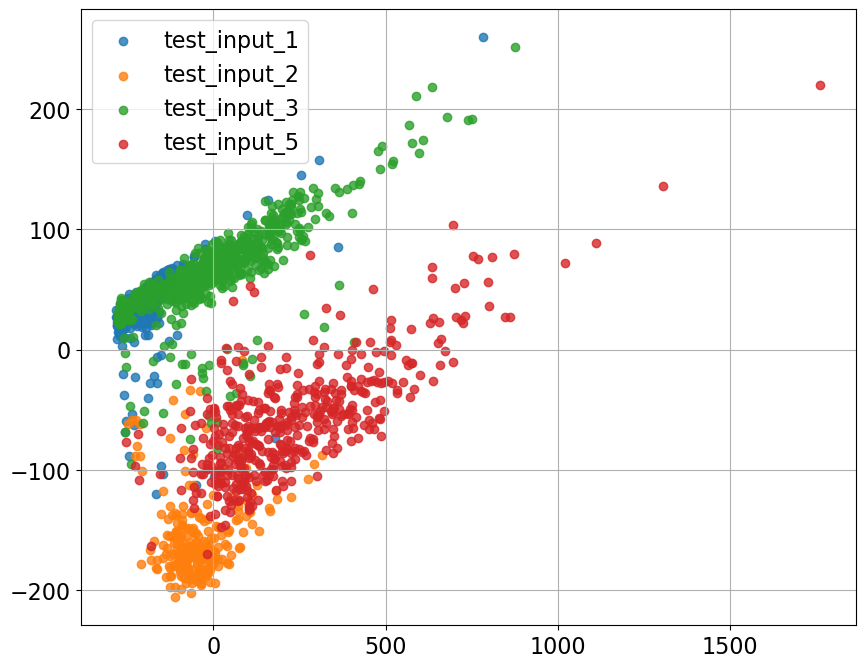

In [15]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
for i in [0, 1, 2, 4]:
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(image_paths[i])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    transformed_data = all_pca.transform(test_image_dataset.values)
    
    ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"test_input_{i+1}")

ax.legend()
ax.grid()
plt.show()

with scaling

In [16]:
scaler = StandardScaler()
all_scaled_pca = PCA(n_components=2)
all_scaled_pca.fit(scaler.fit_transform(all_images_fobjects_dataset.drop(columns = 'ID').values))

PCA(n_components=2)

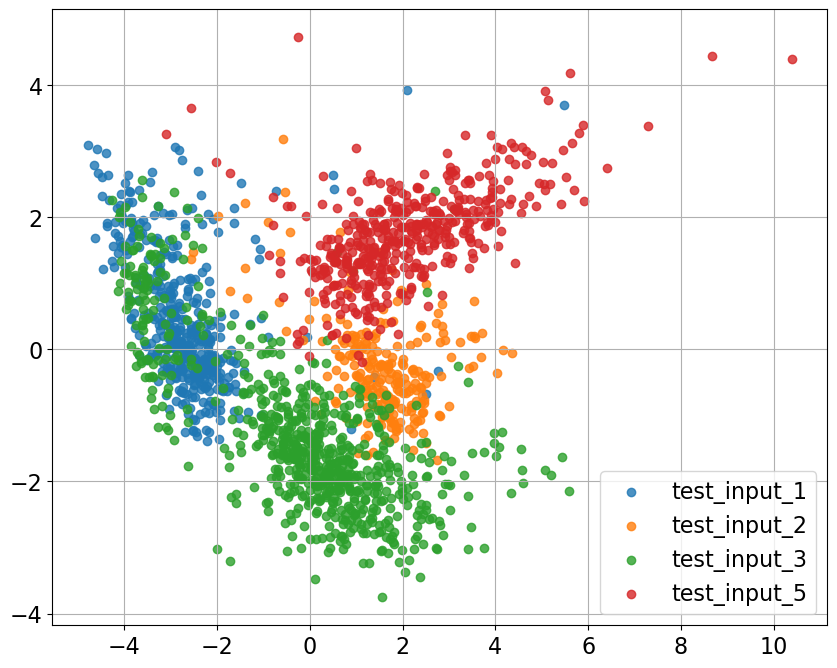

In [17]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
for i in [0, 1, 2, 4]:
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(image_paths[i])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    transformed_data = all_scaled_pca.transform(scaler.transform(test_image_dataset.values))
    
    ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"test_input_{i+1}")

ax.legend()
ax.grid()
plt.show()

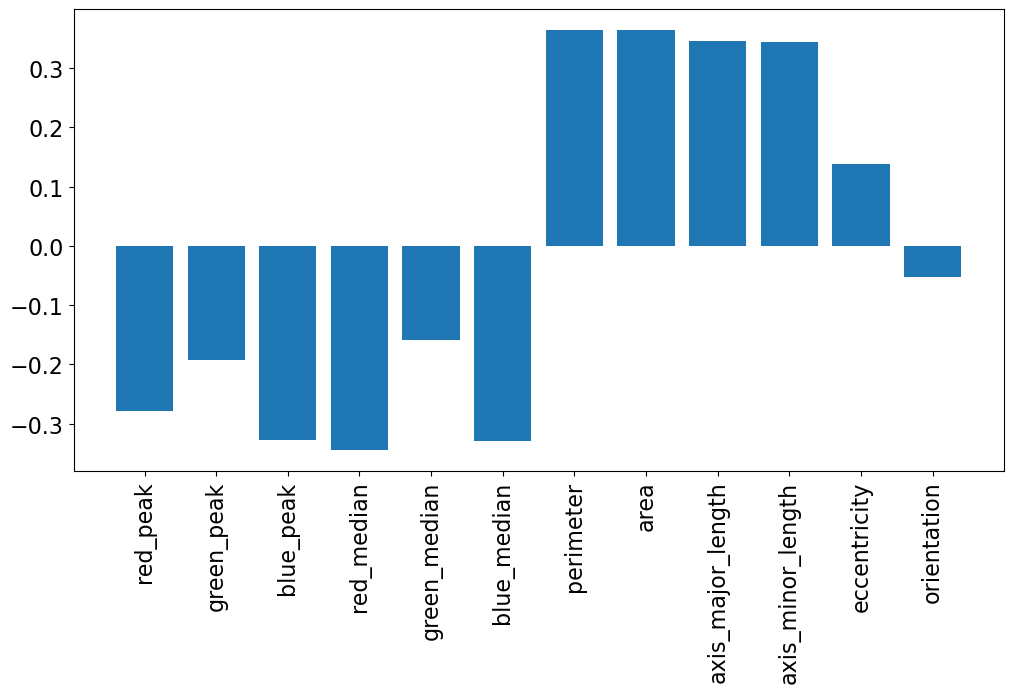

In [18]:
plt.figure(figsize=(12,6))
plt.bar(all_images_fobjects_dataset.drop(columns = 'ID').columns,all_scaled_pca.components_[0])
# plt.bar(all_images_fobjects_dataset.drop(columns = 'ID').columns,all_pca.components_[0])
plt.xticks(rotation=90)
plt.show()

## Biplot (scaled data)

In [19]:
coeff = all_scaled_pca.components_
names = list(all_images_fobjects_dataset.drop(columns = 'ID').columns)

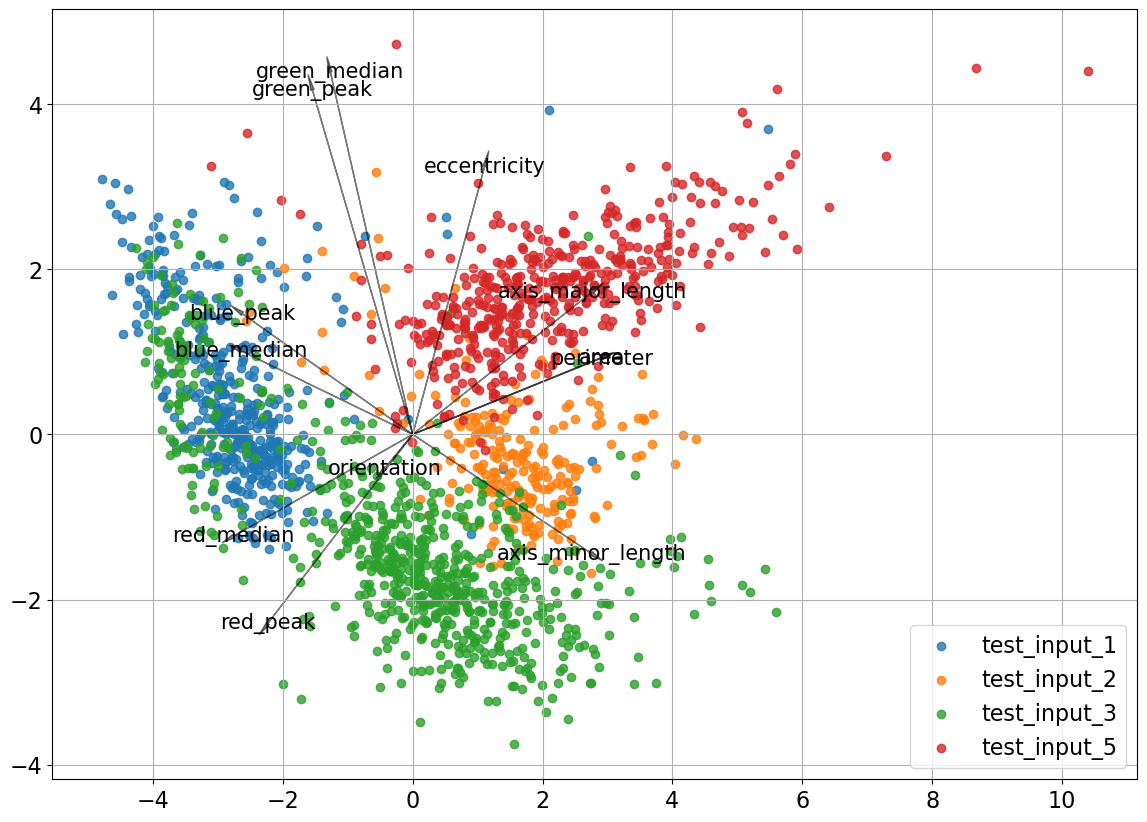

In [20]:
fig, ax = plt.subplots(1,1, figsize=(14,10))
for i in [0, 1, 2, 4]:
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(image_paths[i])
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    transformed_data = all_scaled_pca.transform(scaler.transform(test_image_dataset.values))
    
    ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"test_input_{i+1}")


for i in range(len(names)):
    ax.arrow(0, 0, coeff[0,i]*8, coeff[1,i]*8,color = 'black',alpha = 0.5,
             head_width = 0.05, head_length = 0.2)
    ax.text(coeff[0,i]* 8, coeff[1,i] * 8, names[i], color = 'black', ha = 'center', va = 'center',size = 15)


ax.legend()
ax.grid()
plt.show()

# Analyze all the images, that we have

In [21]:
# r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\All'
# r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_positive\Bacillus'
# r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_positive\Coccus'
# r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_positive\Coccus_Bacillus'
# r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_negative\Bacillus'
# r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_negative\Coccus'

folder_path = os.path.abspath(r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\All')
positive_bacillus_folder_path = os.path.abspath(r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_positive\Bacillus')
positive_coccus_folder_path = os.path.abspath(r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_positive\Coccus')

In [22]:
all_images_fobjects_dataset = pd.DataFrame()
positive_bacillus_images_fobjects_dataset = pd.DataFrame()
positive_coccus_images_fobjects_dataset = pd.DataFrame()
# positive_baccoc_images_fobjects_dataset = pd.DataFrame()
# negative_bacillus_images_fobjects_dataset = pd.DataFrame()
# negative_coccus_images_fobjects_dataset = pd.DataFrame()

for image in tqdm(os.listdir(folder_path)):
    test_image_class = BF_image(verbose=False)
    test_image_class.load_image(os.path.join(folder_path, image))
    test_image_class.preprocess_image()
    test_image_class.segment_image(type='ridges')
    objects_features = test_image_class.all_object_features()
    test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
    test_image_dataset['ID'] = [image + f'_{key}' for key in objects_features]
    all_images_fobjects_dataset = pd.concat((all_images_fobjects_dataset, test_image_dataset))

    if image in os.listdir(positive_bacillus_folder_path):
        positive_bacillus_images_fobjects_dataset = pd.concat((positive_bacillus_images_fobjects_dataset, test_image_dataset))
    elif image in os.listdir(positive_coccus_folder_path):
        positive_coccus_images_fobjects_dataset = pd.concat((positive_coccus_images_fobjects_dataset, test_image_dataset))

  0%|          | 0/59 [00:00<?, ?it/s]

100%|██████████| 59/59 [02:11<00:00,  2.24s/it]


In [23]:
all_images_fobjects_dataset

,red_peak,green_peak,blue_peak,red_median,green_median,blue_median,perimeter,area,axis_major_length,axis_minor_length,eccentricity,orientation,ID
0,255.0,116.0,157.0,254.0,117.0,157.0,89.840620,416.0,35.089800,15.725675,0.893956,-0.028987,"E. coli, 5.bmp_1"
1,254.0,85.0,153.0,248.0,100.0,154.5,63.355339,296.0,21.399352,18.078101,0.535087,-0.723656,"E. coli, 5.bmp_2"
2,255.0,126.0,156.0,253.0,125.0,159.0,75.254834,276.0,25.076710,15.820632,0.775873,-0.814708,"E. coli, 5.bmp_3"
3,255.0,102.0,156.0,255.0,121.0,161.0,92.597980,280.0,34.590903,13.771334,0.917333,0.632669,"E. coli, 5.bmp_4"
4,254.0,82.0,157.0,253.0,116.0,160.0,68.213203,217.0,23.821561,14.088206,0.806374,0.485628,"E. coli, 5.bmp_5"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,255.0,50.0,86.0,255.0,61.0,86.0,19.313708,31.0,7.008801,5.735091,0.574834,-1.341266,Грам- кокки_4.bmp_204
204,255.0,79.0,86.0,255.0,80.0,88.0,21.727922,31.0,8.739961,5.238154,0.800499,-0.104501,Грам- кокки_4.bmp_205
205,255.0,51.0,90.0,255.0,51.0,95.0,20.485281,29.0,7.944245,5.346899,0.739594,-0.621560,Грам- кокки_4.bmp_206
206,255.0,40.0,84.0,255.0,51.5,89.5,19.899495,28.0,9.133621,4.010882,0.898422,0.908476,Грам- кокки_4.bmp_207


In [24]:
scaler = StandardScaler()
all_scaled_pca = PCA(n_components=2)
all_scaled_pca.fit(scaler.fit_transform(all_images_fobjects_dataset.drop(columns = 'ID').values))

PCA(n_components=2)

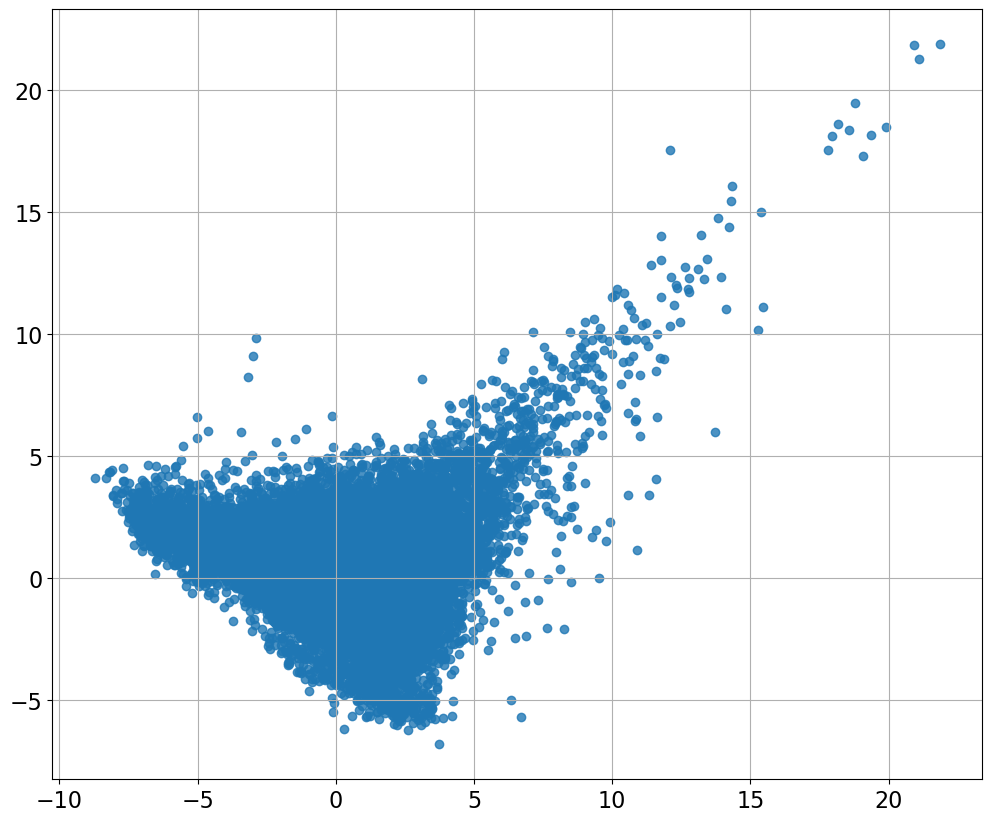

In [25]:
plt.figure(figsize=(12, 10))
transformed_data = all_scaled_pca.transform(scaler.transform(all_images_fobjects_dataset.drop(columns = 'ID').values))
plt.scatter(transformed_data[:,0], transformed_data[:,1], alpha = 0.8)
plt.grid()
plt.show()

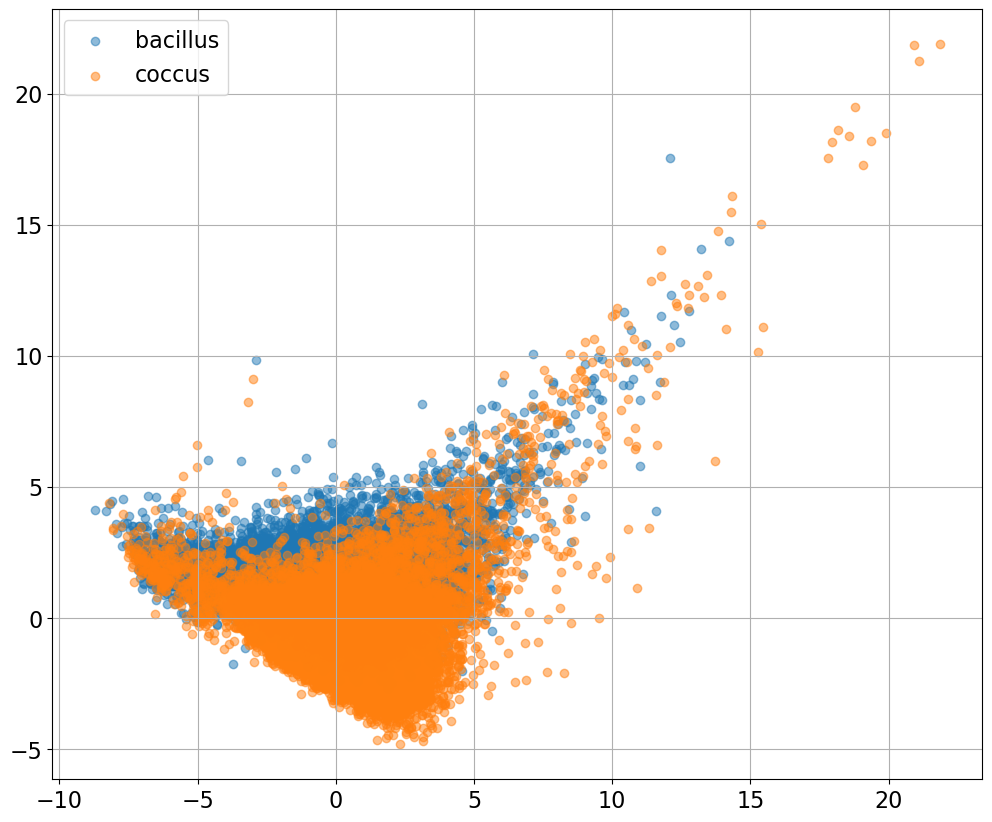

In [26]:
plt.figure(figsize=(12, 10))
transformed_data_bacillus = all_scaled_pca.transform(scaler.transform(positive_bacillus_images_fobjects_dataset.drop(columns = 'ID').values))
transformed_data_coccus = all_scaled_pca.transform(scaler.transform(positive_coccus_images_fobjects_dataset.drop(columns = 'ID').values))
plt.scatter(transformed_data_bacillus[:,0], transformed_data_bacillus[:,1], alpha = 0.5, label='bacillus')
plt.scatter(transformed_data_coccus[:,0], transformed_data_coccus[:,1], alpha = 0.5, label='coccus')
plt.grid()
plt.legend()
plt.show()

In [27]:
coeff = all_scaled_pca.components_
names = list(all_images_fobjects_dataset.drop(columns = 'ID').columns)

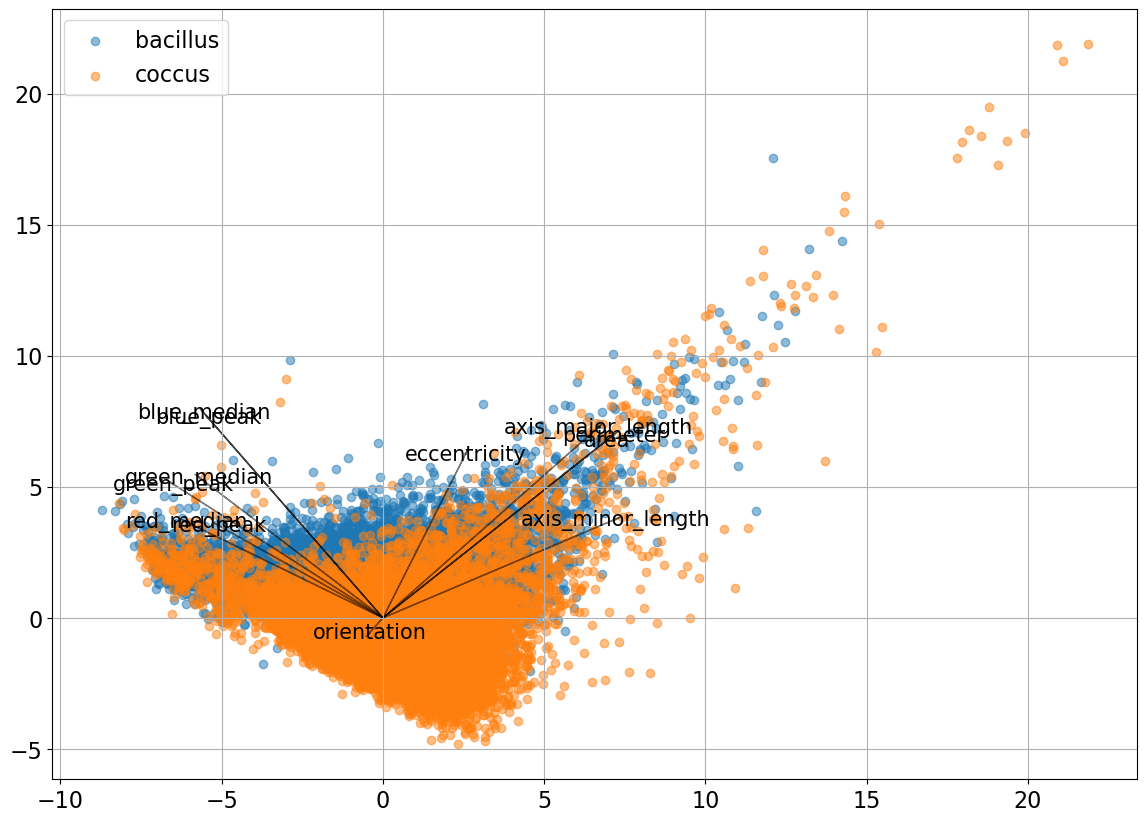

In [28]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

transformed_data_bacillus = all_scaled_pca.transform(scaler.transform(positive_bacillus_images_fobjects_dataset.drop(columns = 'ID').values))
transformed_data_coccus = all_scaled_pca.transform(scaler.transform(positive_coccus_images_fobjects_dataset.drop(columns = 'ID').values))
plt.scatter(transformed_data_bacillus[:,0], transformed_data_bacillus[:,1], alpha = 0.5, label='bacillus')
plt.scatter(transformed_data_coccus[:,0], transformed_data_coccus[:,1], alpha = 0.5, label='coccus')


for i in range(len(names)):
    ax.arrow(0, 0, coeff[0,i]*20, coeff[1,i]*20,color = 'black',alpha = 0.5,
             head_width = 0.05, head_length = 0.2)
    ax.text(coeff[0,i]* 20, coeff[1,i] * 20, names[i], color = 'black', ha = 'center', va = 'center',size = 15)


ax.legend()
ax.grid()
plt.show()

In [29]:
scaler = StandardScaler()
all_scaled_pca_3 = PCA(n_components=3)
all_scaled_pca_3.fit(scaler.fit_transform(all_images_fobjects_dataset.drop(columns = 'ID').values))

PCA(n_components=3)

In [30]:
from mpl_toolkits.mplot3d import axes3d 

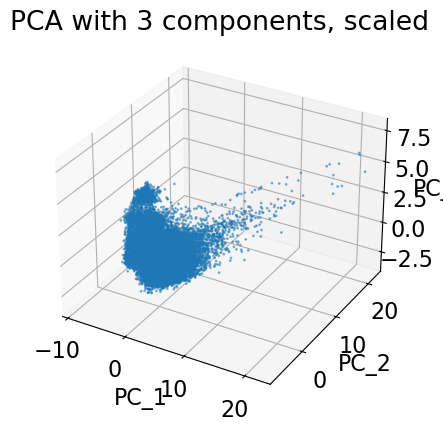

In [31]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

transformed_data = all_scaled_pca_3.transform(scaler.fit_transform(all_images_fobjects_dataset.drop(columns = 'ID').values))

scatter = ax.scatter(transformed_data[:,0], transformed_data[:,1],
           transformed_data[:,2], s = 1, alpha = 0.5)

ax.set_title('PCA with 3 components, scaled')
ax.set_xlabel('PC_1')
ax.set_ylabel('PC_2')
ax.set_zlabel('PC_3')

plt.show()

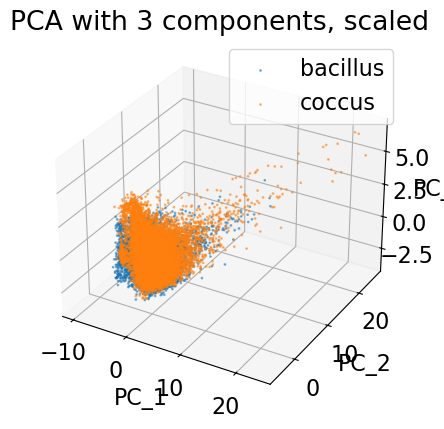

In [32]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

transformed_data_bacillus = all_scaled_pca_3.transform(scaler.fit_transform(positive_bacillus_images_fobjects_dataset.drop(columns = 'ID').values))
transformed_data_coccus = all_scaled_pca_3.transform(scaler.fit_transform(positive_coccus_images_fobjects_dataset.drop(columns = 'ID').values))

ax.scatter(transformed_data_bacillus[:,0], transformed_data_bacillus[:,1],
           transformed_data_bacillus[:,2], s = 1, alpha = 0.5, label='bacillus')
ax.scatter(transformed_data_coccus[:,0], transformed_data_coccus[:,1],
           transformed_data_coccus[:,2], s = 1, alpha = 0.5, label='coccus')

ax.set_title('PCA with 3 components, scaled')
ax.set_xlabel('PC_1')
ax.set_ylabel('PC_2')
ax.set_zlabel('PC_3')

ax.legend()
# ax.view_init(elev, azim, roll)
# ax.view_init(-45, -125, 0)

plt.show()

# Attempt to analyze red and purple cocci

In [33]:
folder_path = os.path.abspath(r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\All')
negative_coccus_folder_path = os.path.abspath(r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_negative\Coccus')
positive_coccus_folder_path = os.path.abspath(r'C:\Users\egork\OneDrive\Рабочий стол\Научная работа\К диплому\Pictures_all_new\Gramm_positive\train_coccus')

In [34]:
negative_coccus_images_fobjects_dataset = pd.DataFrame()
positive_coccus_images_fobjects_dataset = pd.DataFrame()

for image in tqdm(os.listdir(folder_path)):
    if image in os.listdir(negative_coccus_folder_path) or image in os.listdir(positive_coccus_folder_path):
        test_image_class = BF_image(verbose=False)
        test_image_class.load_image(os.path.join(folder_path, image))
        test_image_class.preprocess_image()
        test_image_class.segment_image(type='ridges')
        objects_features = test_image_class.all_object_features()
        test_image_dataset = pd.DataFrame.from_dict([objects_features[key]['color_props'] | objects_features[key]['region_props'] for key in objects_features], dtype=float)
        test_image_dataset['ID'] = [image + f'_{key}' for key in objects_features]

        if image in os.listdir(positive_coccus_folder_path):
            positive_coccus_images_fobjects_dataset = pd.concat((positive_coccus_images_fobjects_dataset, test_image_dataset))
        elif image in os.listdir(negative_coccus_folder_path):
            negative_coccus_images_fobjects_dataset = pd.concat((negative_coccus_images_fobjects_dataset, test_image_dataset))

100%|██████████| 59/59 [00:14<00:00,  3.99it/s]


In [35]:
positive_coccus_images_fobjects_dataset

,red_peak,green_peak,blue_peak,red_median,green_median,blue_median,perimeter,area,axis_major_length,axis_minor_length,eccentricity,orientation,ID
0,117.0,91.0,115.0,145.5,107.0,118.0,77.254834,346.0,30.063698,14.926224,0.868044,1.175795,Г+ кокки_11.bmp_1
1,95.0,91.0,113.0,121.0,106.0,121.0,73.355339,345.0,28.651360,15.574387,0.839356,-1.295169,Г+ кокки_11.bmp_2
2,107.0,97.0,132.0,122.5,120.5,128.0,68.769553,292.0,28.454518,13.257125,0.884834,1.088551,Г+ кокки_11.bmp_3
3,127.0,86.0,120.0,144.0,107.0,122.0,71.526912,291.0,28.265613,13.313027,0.882135,0.040476,Г+ кокки_11.bmp_4
4,111.0,87.0,113.0,143.0,117.0,120.0,65.597980,283.0,22.742058,16.681841,0.679664,1.256482,Г+ кокки_11.bmp_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,181.0,110.0,135.0,194.0,110.0,135.0,26.384776,53.0,9.648906,7.280139,0.656295,1.097092,Г+ кокки_15.bmp_415
415,145.0,129.0,116.0,162.0,143.5,122.0,26.828427,44.0,13.105211,4.303244,0.944552,-1.510947,Г+ кокки_15.bmp_416
416,156.0,104.0,124.0,165.5,128.0,126.0,18.656854,26.0,8.105534,4.472635,0.833976,1.480175,Г+ кокки_15.bmp_417
417,218.0,147.0,147.0,217.5,147.0,147.0,12.242641,16.0,5.244535,3.920440,0.664230,0.301144,Г+ кокки_15.bmp_418


In [36]:
scaler = StandardScaler()
all_scaled_pca = PCA(n_components=2)
all_scaled_pca.fit(scaler.fit_transform(pd.concat((positive_coccus_images_fobjects_dataset, negative_coccus_images_fobjects_dataset)).drop(columns = 'ID')))

PCA(n_components=2)

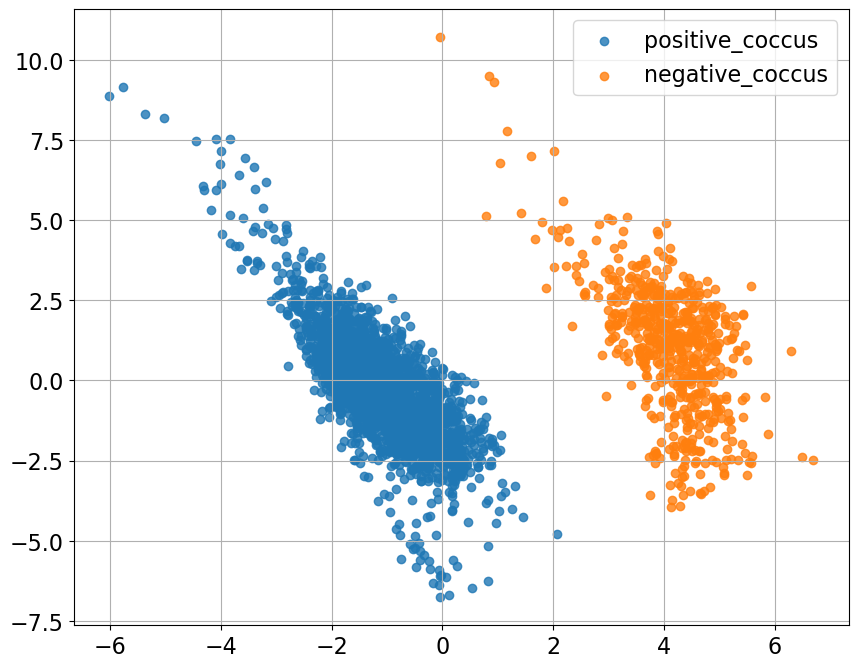

In [37]:
fig, ax = plt.subplots(1,1, figsize=(10,8))

transformed_data = all_scaled_pca.transform(scaler.transform(positive_coccus_images_fobjects_dataset.drop(columns = 'ID')))
ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"positive_coccus")

transformed_data = all_scaled_pca.transform(scaler.transform(negative_coccus_images_fobjects_dataset.drop(columns = 'ID')))
ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"negative_coccus")

ax.legend()
ax.grid()
plt.show()

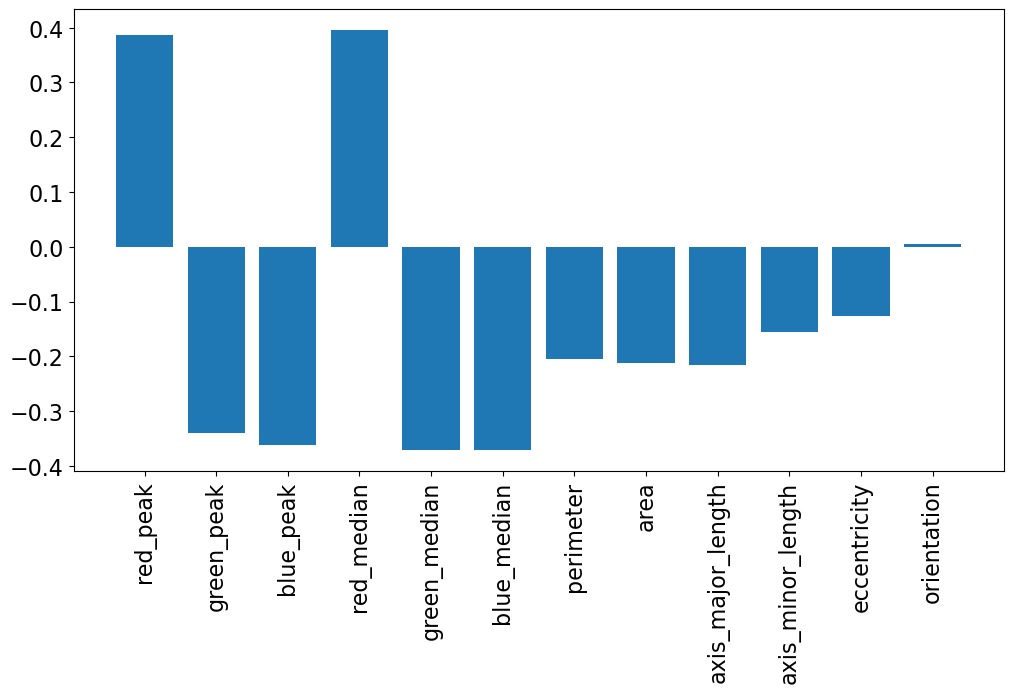

In [38]:
plt.figure(figsize=(12,6))
plt.bar(positive_coccus_images_fobjects_dataset.drop(columns = 'ID').columns,all_scaled_pca.components_[0])
# plt.bar(all_images_fobjects_dataset.drop(columns = 'ID').columns,all_pca.components_[0])
plt.xticks(rotation=90)
plt.show()

## Biplot (scaled data)

In [39]:
coeff = all_scaled_pca.components_
names = list(positive_coccus_images_fobjects_dataset.drop(columns = 'ID').columns)

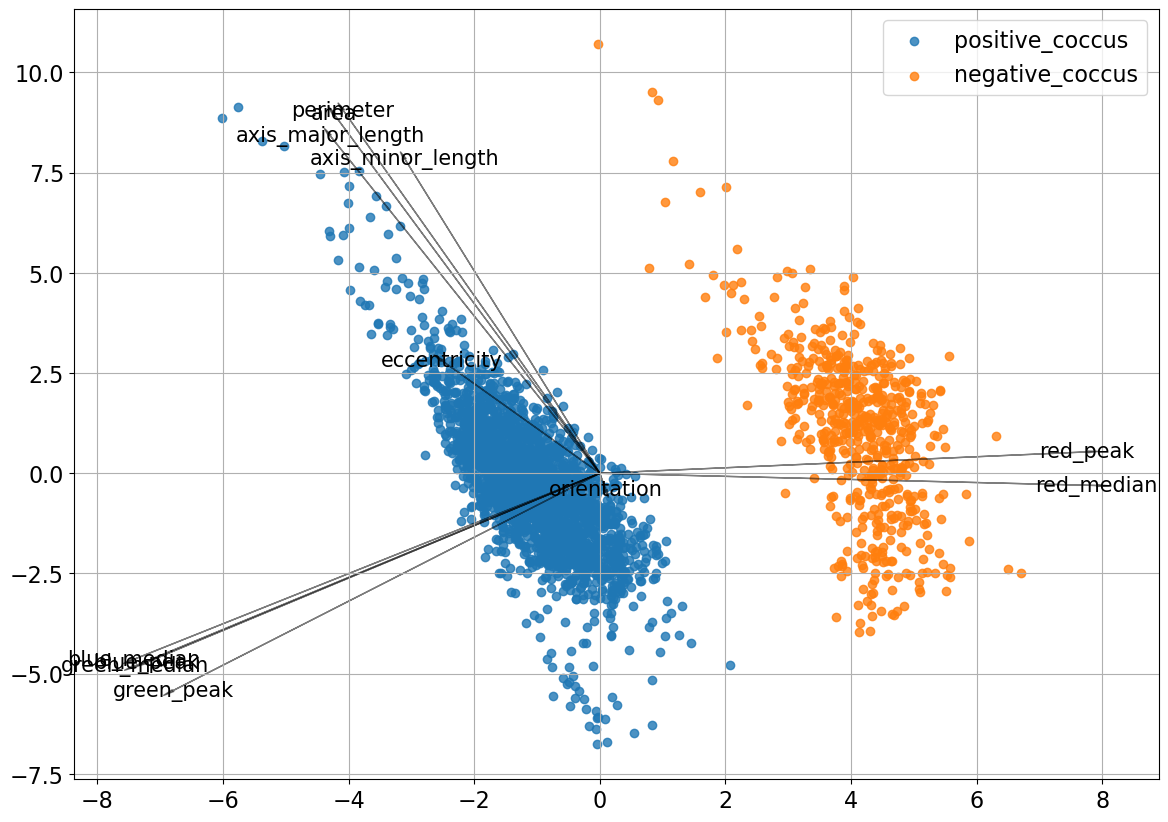

In [40]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

transformed_data = all_scaled_pca.transform(scaler.transform(positive_coccus_images_fobjects_dataset.drop(columns = 'ID')))
ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"positive_coccus")

transformed_data = all_scaled_pca.transform(scaler.transform(negative_coccus_images_fobjects_dataset.drop(columns = 'ID')))
ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"negative_coccus")

for i in range(len(names)):
    ax.arrow(0, 0, coeff[0,i]*20, coeff[1,i]*20,color = 'black',alpha = 0.5,
             head_width = 0.05, head_length = 0.2)
    ax.text(coeff[0,i]* 20, coeff[1,i] * 20, names[i], color = 'black', ha = 'center', va = 'center',size = 15)


ax.legend()
ax.grid()
plt.show()

## SVM classification

In [41]:
negative_coccus_images_fobjects_dataset['type'] = 1
positive_coccus_images_fobjects_dataset['type'] = 0

In [42]:
pn_coccus_images_fobjects_dataset = pd.concat((positive_coccus_images_fobjects_dataset, negative_coccus_images_fobjects_dataset)).drop(columns = 'ID')

In [43]:
train_pn_dataset, test_pn_dataset = train_test_split(pn_coccus_images_fobjects_dataset, test_size=0.2, stratify=pn_coccus_images_fobjects_dataset['type'])

In [44]:
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=42))

In [45]:
clf.fit(all_scaled_pca.transform(scaler.transform(train_pn_dataset.drop(columns = 'type'))), train_pn_dataset['type'])

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(kernel='linear', random_state=42))])

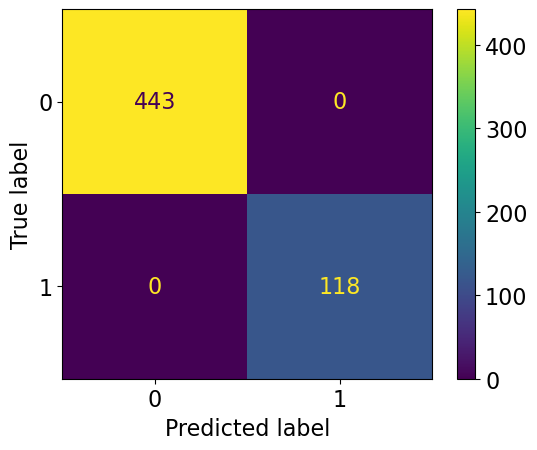

In [46]:
cm = confusion_matrix(test_pn_dataset['type'], clf.predict(all_scaled_pca.transform(scaler.transform(test_pn_dataset.drop(columns = 'type')))), labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

plt.show()

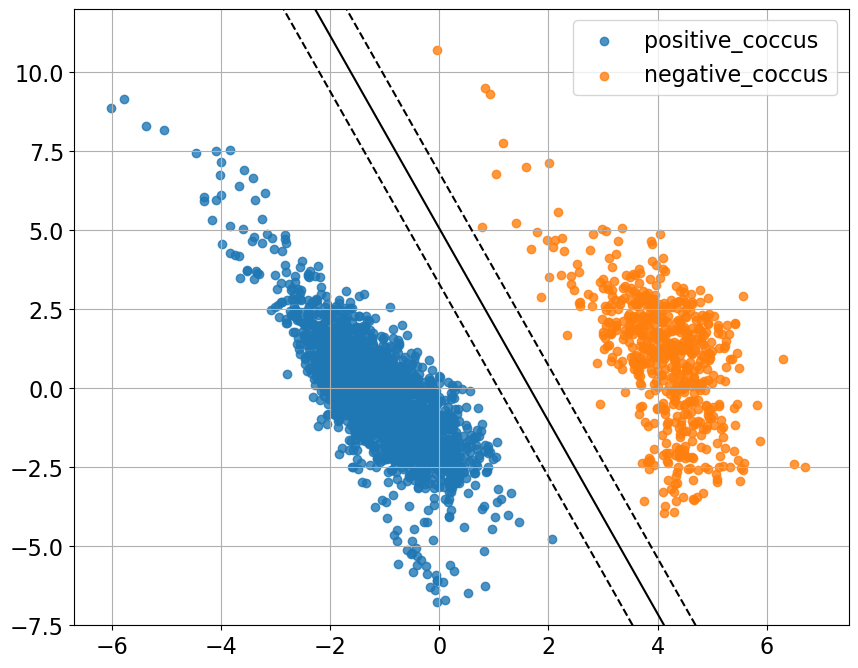

In [49]:
fig, ax = plt.subplots(1,1, figsize=(10,8))

transformed_data = all_scaled_pca.transform(scaler.transform(positive_coccus_images_fobjects_dataset.drop(columns = ['ID', 'type'])))
ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"positive_coccus")

transformed_data = all_scaled_pca.transform(scaler.transform(negative_coccus_images_fobjects_dataset.drop(columns = ['ID', 'type'])))
ax.scatter(transformed_data[:,0], transformed_data[:,1], alpha=0.8, label=f"negative_coccus")

ax.legend()
ax.grid()

XX, YY = np.mgrid[-5:7.5:200j, -7.5:12:200j]
Z = clf.decision_function(np.c_[XX.ravel(), YY.ravel()])

# Put the result into a color plot
Z = Z.reshape(XX.shape)
ax.contour(
    XX,
    YY,
    Z,
    colors=["k", "k", "k"],
    linestyles=["--", "-", "--"],
    levels=[-0.5, 0, 0.5],
)